In [1]:
! pip install segmentation-models-pytorch albumentations scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01


In [2]:
import glob
import os
import random
import sys
import pandas as pd
sys.path.append('/kaggle/input/datasets/skimaks/losses')

import albumentations as A
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import KFold
from losses import ComboLoss

In [3]:
SEED = 60

def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

    os.environ['PYTHONHASHSEED'] = str(SEED)
    os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
    os.environ['CUDA_VISIBLE_DEVICES']= '1'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 4

In [24]:
def plot_images_side_by_side(image1, image2, title1='', title2=''):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    axs[0].imshow(image1)
    axs[0].set_title(title1)
    axs[0].axis('off')
    
    axs[1].imshow(image2)
    axs[1].set_title(title2)
    axs[1].axis('off')
    
    plt.show()


def dice_channels(prob, truth, threshold=0.5, eps = 1E-9):
    num_imgs = prob.size(0)
    num_channels = prob.size(1)
    prob = (prob > threshold).float()
    truth = (truth > 0.5).float()
    prob = prob.view(num_imgs, num_channels, -1)
    truth = truth.view(num_imgs, num_channels, -1)
    intersection = (prob * truth)
    score = (2. * intersection.sum(2) + eps) / (prob.sum(2) + truth.sum(2) + eps)
    score[score >= 1] = 1
    return score.mean()


def train_epoch(loader, model, loss_function_seg, optimizer, device, threshold=0.3):
    model = model.to(device)
    model.train()
    avg_loss = 0.
    avg_dice = 0.
    optimizer.zero_grad()
    for image, mask in loader:
        x = image.to(device)
        y = mask.to(device)
        prediction_seg = model(x)
        loss = loss_function_seg(prediction_seg, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        avg_loss += loss.item()
        with torch.no_grad():
            probs = torch.sigmoid(prediction_seg)
            avg_dice += dice_channels(probs, y, threshold=threshold).item()
            
    avg_loss /= len(loader)
    avg_dice /= len(loader)
    return avg_loss, avg_dice


def valid_epoch(loader, model, device, threshold=0.3):
    scores = []
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        for image, mask in loader:
            x = image.to(device)
            y = mask.to(device)
            probs = torch.sigmoid(model(x))
            scores.append(dice_channels(probs, y, threshold=threshold))

    return torch.stack(scores).mean().item()

In [36]:
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomResizedCrop(
        size=(512, 512),
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1),
        p=0.5
    ),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.0, 0.02),
        rotate=(-10, 10),
        shear=(-5, 5),
        p=0.5
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.6
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=10,
        val_shift_limit=10,
        p=0.4
    ),
    A.ImageCompression(quality_range=(80, 100), p=0.2),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.15),
    A.GaussianBlur(blur_limit=3, p=0.1),
    A.Resize(512, 512),
    A.Normalize(),
])

test_transforms = A.Compose([
    A.Resize(512, 512),
    A.Normalize(),
])

In [37]:
class SegmentationDataset(Dataset):
    def __init__(self, img_paths, masks_paths, transforms):
        self.img_paths = img_paths
        self.masks_paths = masks_paths
        self.transforms = transforms
        
    def __getitem__(self, item):
        img_path = self.img_paths[item]
        mask_path = self.masks_paths[item]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = np.load(mask_path)
        
        transformed_data = self.transforms(image=img, mask=mask)
        img = transformed_data['image']
        mask = transformed_data['mask']

        return torch.from_numpy(img).permute(2, 0, 1), torch.from_numpy(mask).permute(2, 0, 1).float()
    
    def __len__(self):
        return len(self.img_paths)

In [38]:
img_path = sorted(glob.glob('/kaggle/input/datasets/skimaks/segmentation-data/data/train/images/*.jpg'))[1]
mask_path = sorted(glob.glob('/kaggle/input/datasets/skimaks/segmentation-data/data/train/masks/*.npy'))[1]
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = np.load(mask_path)

transformed_data = train_transforms(image=img, mask=mask)
transformed_img = transformed_data['image']
transformed_mask = transformed_data['mask']

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].


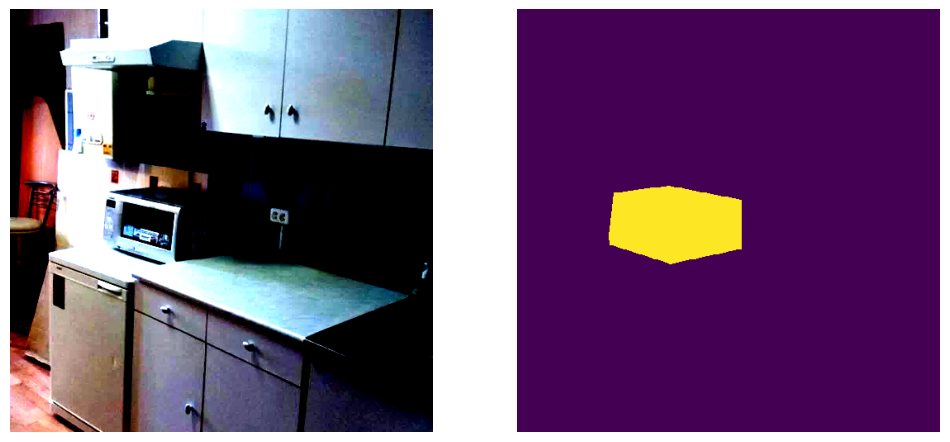

In [39]:
plot_images_side_by_side(transformed_img, transformed_mask[:,:,2])

In [40]:
all_train_images = sorted(glob.glob('/kaggle/input/datasets/skimaks/segmentation-data/data/train/images/*.jpg'))
all_train_masks = sorted(glob.glob('/kaggle/input/datasets/skimaks/segmentation-data/data/train/masks/*.npy'))
all_test_images = sorted(glob.glob('/kaggle/input/datasets/skimaks/segmentation-data/data/test/images/*.jpg'))

In [ ]:
# Определим весовые коэффициенты классов, опираясь на частоту пикселей по классам (pixel_freq)
num_classes = 4
pixel_counts = np.zeros(num_classes, dtype=np.float32)

for path in all_train_masks:
    mask = np.load(path)
    pixel_counts += mask.reshape(-1, num_classes).sum(axis=0).astype(np.float32)

pixel_freq = pixel_counts / pixel_counts.sum()
cw = 1.0 / np.sqrt(pixel_freq + 1e-12)
cw = (cw / cw.mean()).tolist()

print("pixel_counts:", pixel_counts)
print("pixel_freq  :", np.round(pixel_freq, 6))

pixel_counts: [ 499350. 1685726.  421934.  122247.]
pixel_freq  : [0.182962 0.61765  0.154597 0.044791]


In [42]:
def build_model_fn():
    return smp.FPN(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        classes=4,
        activation=None,
    )

def make_loss_fn():
    return ComboLoss(weights={'bce': 1, 'dice': 0}, channel_weights=cw)

def optimizer_fn(model):
    return torch.optim.Adam(model.parameters(), lr=2e-4)

In [43]:
K = 5
N_EPOCH = 60
kf = KFold(n_splits=K, shuffle=True, random_state=SEED)

fold_best_scores = []
fold_best_states = []

idx_all = np.arange(len(all_train_images))
for fold, (tr_idx, va_idx) in enumerate(kf.split(idx_all), start=1):
    print(f"\n===== FOLD {fold}/{K} | epochs={N_EPOCH}")

    train_images = [all_train_images[i] for i in tr_idx]
    train_masks  = [all_train_masks[i]  for i in tr_idx]
    valid_images = [all_train_images[i] for i in va_idx]
    valid_masks  = [all_train_masks[i]  for i in va_idx]

    train_dataset = SegmentationDataset(train_images, train_masks, train_transforms)
    valid_dataset = SegmentationDataset(valid_images, valid_masks, test_transforms)

    train_loader = DataLoader(train_dataset, BATCH_SIZE, num_workers=4, shuffle=True)
    valid_loader = DataLoader(valid_dataset, BATCH_SIZE, num_workers=4, shuffle=False)

    model = build_model_fn().to(device)
    loss_fn = make_loss_fn()
    optimizer = optimizer_fn(model)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, N_EPOCH),
        eta_min=1e-4
    )

    best_score = -1.0
    best_state = None
    best_epoch = -1

    for epoch in range(N_EPOCH):
        train_loss, train_dice = train_epoch(train_loader, model, loss_fn, optimizer, device)
        valid_score = valid_epoch(valid_loader, model, device, threshold=0.3)
        scheduler.step()
        cur_lr = optimizer.param_groups[0]["lr"]
        if valid_score > best_score:
            best_score = valid_score
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(
            f"Fold {fold} | Epoch {epoch:02d} | "
            f"lr {cur_lr:.2e} | "
            f"loss {train_loss:.4f} | "
            f"train_dice {train_dice:.3f} | "
            f"val_dice {valid_score:.3f}"
        )

    # финальная оценка
    valid_score_final = valid_epoch(valid_loader, model, device, threshold=0.3)
    fold_best_scores.append(best_score)
    fold_best_states.append(best_state)

    print(f"FOLD {fold} BEST (epoch={best_epoch}): {best_score:.4f}")
    print(f"FOLD {fold} FINAL            : {valid_score_final:.4f}")

print("best mean:", float(np.mean(fold_best_scores)))


===== FOLD 1/5 | epochs=60
Fold 1 | Epoch 00 | lr 2.00e-04 | loss 0.1124 | train_dice 0.319 | val_dice 0.391
Fold 1 | Epoch 01 | lr 2.00e-04 | loss 0.0407 | train_dice 0.440 | val_dice 0.390
Fold 1 | Epoch 02 | lr 1.99e-04 | loss 0.0302 | train_dice 0.494 | val_dice 0.453
Fold 1 | Epoch 03 | lr 1.99e-04 | loss 0.0209 | train_dice 0.556 | val_dice 0.530
Fold 1 | Epoch 04 | lr 1.98e-04 | loss 0.0175 | train_dice 0.609 | val_dice 0.486
Fold 1 | Epoch 05 | lr 1.98e-04 | loss 0.0189 | train_dice 0.627 | val_dice 0.428
Fold 1 | Epoch 06 | lr 1.97e-04 | loss 0.0154 | train_dice 0.653 | val_dice 0.545
Fold 1 | Epoch 07 | lr 1.96e-04 | loss 0.0139 | train_dice 0.670 | val_dice 0.538
Fold 1 | Epoch 08 | lr 1.95e-04 | loss 0.0116 | train_dice 0.708 | val_dice 0.550
Fold 1 | Epoch 09 | lr 1.93e-04 | loss 0.0186 | train_dice 0.688 | val_dice 0.408
Fold 1 | Epoch 10 | lr 1.92e-04 | loss 0.0145 | train_dice 0.669 | val_dice 0.523
Fold 1 | Epoch 11 | lr 1.90e-04 | loss 0.0122 | train_dice 0.703 | val

## Подбор оптимальных порогов по классам

### 1) OOF-предикты (prob) и GT на всём train

In [44]:
def build_and_load_model(state_dict_cpu):
    m = build_model_fn().to(device)
    clean_state = {k.replace("module.", ""): v for k, v in state_dict_cpu.items() if k != "n_averaged"}
    m.load_state_dict(clean_state, strict=True)
    m.eval()
    return m

In [45]:
# Готовим место под OOF probs и GT
N = len(all_train_images)
C = 4
H = W = 512
oof_probs = np.zeros((N, C, H, W), dtype=np.float32)
oof_gt    = np.zeros((N, C, H, W), dtype=np.uint8)

# Собираем GT один раз
gt_dataset = SegmentationDataset(all_train_images, all_train_masks, test_transforms)
gt_loader  = DataLoader(gt_dataset, BATCH_SIZE, num_workers=4, shuffle=False)

# Сохраним GT в правильном порядке
with torch.no_grad():
    idx_ptr = 0
    for x, y in gt_loader:
        b = x.shape[0]
        oof_gt[idx_ptr:idx_ptr+b] = (y.numpy() > 0.5).astype(np.uint8)
        idx_ptr += b

# OOF-предикты: для каждого фолда прогоняем его модель только на его va_idx
idx_all = np.arange(N)
kf = KFold(n_splits=K, shuffle=True, random_state=SEED)
fold_states_for_oof = fold_best_states

for fold, ((tr_idx, va_idx), st) in enumerate(zip(kf.split(idx_all), fold_states_for_oof), start=1):
    print(f"OOF predict fold {fold}/{K} on {len(va_idx)} samples")
    model = build_and_load_model(st)
    va_images = [all_train_images[i] for i in va_idx]
    va_masks  = [all_train_masks[i]  for i in va_idx]
    va_ds = SegmentationDataset(va_images, va_masks, test_transforms)
    va_ld = DataLoader(va_ds, BATCH_SIZE, num_workers=4, shuffle=False)

    with torch.no_grad():
        ptr = 0
        for x, _ in va_ld:
            x = x.to(device).float()
            probs = torch.sigmoid(model(x)).cpu().numpy().astype(np.float32)
            b = probs.shape[0]
            oof_probs[va_idx[ptr:ptr+b]] = probs
            ptr += b

OOF predict fold 1/5 on 24 samples
OOF predict fold 2/5 on 24 samples
OOF predict fold 3/5 on 24 samples
OOF predict fold 4/5 on 24 samples
OOF predict fold 5/5 on 24 samples


### 2) Подбор per-class thresholds (grid search)

In [46]:
def dice_from_bin(pred_bin, gt_bin, eps=1e-9):
    """
    Реализация Dice coefficient для бинарной сегментации
    pred_bin, gt_bin: np.uint8 0/1, shape [N,H,W]
    """
    inter = (pred_bin & gt_bin).sum(axis=(1,2))
    union = pred_bin.sum(axis=(1,2)) + gt_bin.sum(axis=(1,2))
    dice = (2*inter + eps) / (union + eps)
    return dice.mean()

In [47]:
grid = np.arange(0.05, 0.66, 0.02)
best_thr = []
best_dice = []

for c in range(4):
    gt_c = oof_gt[:, c].astype(np.uint8)
    probs_c = oof_probs[:, c]
    best_t, best_s = 0.3, -1
    for t in grid:
        pred_c = (probs_c > t).astype(np.uint8)
        s = dice_from_bin(pred_c, gt_c)
        if s > best_s:
            best_s, best_t = s, t

    best_thr.append(float(best_t))
    best_dice.append(float(best_s))
    print(f"class {c}: best_thr={best_t:.2f}, dice={best_s:.4f}")

print("best_thr:", best_thr)
print("mean per-class dice:", float(np.mean(best_dice)))

class 0: best_thr=0.19, dice=0.5515
class 1: best_thr=0.53, dice=0.8206
class 2: best_thr=0.27, dice=0.7882
class 3: best_thr=0.27, dice=0.7432
best_thr: [0.19, 0.5300000000000001, 0.27, 0.27]
mean per-class dice: 0.7258727764348597


In [48]:
def mask2rle(mask):
    '''
    mask: numpy array, 1 - pixel classified as target, 0 - background
    Returns run length as string formated
    '''
    rles = []
    for channel in range(mask.shape[2]):
        channel_mask = mask[:, :, channel]
        pixels = channel_mask.T.flatten()
        pixels = np.concatenate([[0], pixels, [0]])
        runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
        runs[1::2] -= runs[::2]
        rle_channel = ' '.join(str(x) for x in runs)
        rles.append(rle_channel)
    return ';'.join(rles)
 
def get_submission_df(img_paths, transforms, model, best_thr, device='cuda'):
    '''
    img_paths: list of paths to test images
    transforms: albumentation test transforms
    model: the trained model
    bect_thr: per-class probability thresholds
    Returns submission dataframe
    '''
    model = model.to(device)
    model.eval()
    thr_np = np.array(best_thr, dtype=np.float32).reshape(1, 1, 4)
    submission_df = pd.DataFrame()
    c = 0
    with torch.no_grad():
        for n, img_path in enumerate(img_paths):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            transformed_data = transforms(image=img)
            transformed_img = transformed_data['image']

            model_input = torch.from_numpy(transformed_img).permute(2, 0, 1).unsqueeze(0).float().to(device)

            pred = model(model_input)
            probs = torch.sigmoid(pred).squeeze(0).cpu().numpy().astype(np.float32)

            probs_hw = cv2.resize(
                probs.transpose(1, 2, 0),
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_LINEAR
            ).astype(np.float32)

            mask_hw = (probs_hw > thr_np).astype(np.uint8)
            submission_df.loc[c, 'image_id'] = os.path.basename(img_path)
            submission_df.loc[c, 'rle'] = mask2rle(mask_hw)
            submission_df.loc[c, 'batch_number'] = c
            c += 1

    return submission_df

In [49]:
class EnsembleModel(torch.nn.Module):
    """
    Ансамбль моделей по фолдам.
    Предсказание ансамбля - среднее логитов К моделей.
    """
    def __init__(self, build_model_fn, fold_states):
        super().__init__()
        self.models = torch.nn.ModuleList()
        for st in fold_states:
            m = build_model_fn()
            clean_state = {k.replace("module.", ""): v for k, v in st.items() if k != "n_averaged"}
            m.load_state_dict(clean_state, strict=True)
            self.models.append(m)

    def forward(self, x):
        logits_sum = None
        for m in self.models:
            logits = m(x)
            logits_sum = logits if logits_sum is None else (logits_sum + logits)
        return logits_sum / len(self.models)

In [56]:
ensemble_model = EnsembleModel(build_model_fn, fold_best_states)

submission_df = get_submission_df(all_test_images, test_transforms, ensemble_model, best_thr, device=device)
submission_df.to_csv(
    'solution.csv',
    header=['image_id', 'rle', 'batch_number'],
    index=False
)